In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import myfunction as mf
from path_config import *
list_color = ["#4d8cbf", "#4f9c8b", "#555c6c", "#d77563", "#7d84a8", "#84aeb8", "#c3473b", "#89756d","#ffb3cc","#9a7ebf","#ffddb8", "#c4eaff", "#d1c6ff", "#c2ffbf", "#f5f5b0"]

# 划分PFAS
df_po_treat = pd.read_excel(path_file + inf_file, sheet_name="po_treat")
list_pfas_all = df_po_treat['posname'].tolist()
list_pfas_all_lc = df_po_treat[df_po_treat['po_chain']==1]['posname'].tolist()
list_pfas_all_sc = df_po_treat[df_po_treat['po_chain']==0]['posname'].tolist()
print(len(list_pfas_all_lc))
print(len(list_pfas_all_sc))
list_list_pfas = [list_pfas_all, list_pfas_all_lc, list_pfas_all_sc]
classification_dict = df_po_treat.groupby('po_classification')['posname'].apply(list).to_dict()
print(classification_dict)
list_pfas_classification = list(classification_dict.keys())
print(len(list_pfas_classification))
print(list_pfas_classification)

list_color_classfition = ["#acb4cc", "#8bd0e3", "#808eaf", "#6abeae", "#f7bba8", "#b5e0d5", "#ee877c"]
dic_color_classfication = dict(zip(list_pfas_classification,list_color_classfition))

37
23
{'PASFs': ['FOSA', 'MeFOSA', 'EtFOSA', 'MeFOSAA', 'EtFOSAA', 'FBSA', 'EtFOSE', 'MeFOSE', 'FOSAA', 'MeFBSE', 'FHxSA'], 'PFAIs': ['6:2 diPAP', '8:2 diPAP', '6:2 FTSA', '8:2 FTCA', '10:2 FTCA', '4:2 FTSA', '8:2 FTSA', '7:3 FTCA', '6:2/8:2 diPAP', '10:2 FTOH', '6:2 FTOH', '6:2 FTCA', '8:2 FTOH', '6:2 monoPAP', '8:2 monoPAP', '10:2 FTSA', '3:3 FTCA', '5:3 FTCA', '4:2 FTOH'], 'PFCAs': ['PFNA', 'PFHpA', 'PFOA', 'PFDA', 'PFBA', 'PFHxA', 'PFTeDA', 'PFDoDA', 'PFUnDA', 'PFTrDA', 'PFPeDA', 'PFHxDA', 'PFODA', 'PFPeA', 'PFPrA'], 'PFECAs': ['PF5OHxA', 'PF4OPeA', 'HFPO-DA', 'ADONA'], 'PFESAs': ['PFECHS', '6:2 Cl-PFESA'], 'PFPIAs': ['6:8 PFPIA'], 'PFSAs': ['PFOS', 'PFDS', 'PFBS', 'PFHxS', 'PFPeS', 'PFHpS', 'PFNS', 'PFPrS']}
7
['PASFs', 'PFAIs', 'PFCAs', 'PFECAs', 'PFESAs', 'PFPIAs', 'PFSAs']


In [24]:
print(dic_color_classfication)

{'PASFs': '#ee877c', 'PFAIs': '#8bd0e3', 'PFCAs': '#808eaf', 'PFECAs': '#6abeae', 'PFESAs': '#f7bba8', 'PFPIAs': '#b5e0d5', 'PFSAs': '#acb4cc'}


In [ ]:



import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


def draw_year_lm(df, path_save, int_max_y=20, str_unit='ng/l'):
    sns.set_theme(style="ticks")
    df_hem_line = df.copy()
    x = "year"
    y = "value"
    hue = "type"
    order = ["LC-PFAS", 'SC-PFAS']
    color_select = ["#e76361", "#808dae"]
    palette = {"LC-PFAS": "#4f9c8b", "SC-PFAS": "#4d8cbf"}
    ax = sns.lmplot(
        data=df_hem_line,
        x=x, y=y, hue=hue,
        height=5,
        palette=palette,legend=False, scatter=False,
        ci=95,
    )
    ax.set(ylim=(0,int_max_y))

    plt.xlabel('', fontsize=18)
    plt.ylabel("", fontsize=18)



    ax1 = ax.axes[0,0]
    df_hum_data1 = df_hem_line[df_hem_line[hue]==order[1]]
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_hum_data1[x], df_hum_data1[y])
    reg_eq = "y = {:.4f}x + {:.4f}".format(slope, intercept)
    annot = "{}\np = {:.2e}\n{}".format(order[1], p_value, reg_eq)  # 修改此处
    ax1.annotate(annot, xy=(0.58, 0.99), xycoords="axes fraction",
                        fontsize=12, ha="left", va="top")

    ax2 = ax.axes[0,0]
    df_hum_data2 = df_hem_line[df_hem_line[hue]==order[0]]
    slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(df_hum_data2[x], df_hum_data2[y])
    reg_eq2 = "y = {:.4f}x + {:.4f}".format(slope2, intercept2)
    annot2 = "{}\np = {:.2e}\n{}".format(order[0], p_value2, reg_eq2)  # 修改此处
    ax2.annotate(annot2, xy=(0.05, 0.99), xycoords="axes fraction",
                        fontsize=12, ha="left", va="top")

    plt.gcf().set_size_inches(5, 3)




    ax = plt.gca()

    handles, labels = ax.get_legend_handles_labels()
    if isinstance(palette, dict):
        line_handles = [plt.Line2D([0], [0], color=palette[label], lw=2) for label in labels]
    else:

        line_handles = [plt.Line2D([0], [0], color=color, lw=2) for color in palette[:len(labels)]]



    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)
    plt.subplots_adjust(left=0.15,right=0.95,bottom=0.15,top=0.7)

    plt.savefig(path_save, dpi = 180)
    plt.show()
    return print('okk')

def draw_year_line(data, path_save, int_max_y=20,  str_unit='ng/l'):
    custom_params = {"axes.spines.right": False, "axes.spines.top": False}
    sns.set_theme(style="ticks", rc=custom_params)
    fig, ax = plt.subplots()
    plt.gcf().set_size_inches(5, 3)


    sns.lineplot(x="year", y="value", data=data, color="#555c6c", label="Sum-PFAS", marker='D', legend=False)
    sns.lineplot(x="year", y="lc_value", data=data, color="#4f9c8b", label="LC-PFAS", marker='D', legend=False)
    sns.lineplot(x="year", y="sc_value", data=data, color="#4d8cbf", label="SC-PFAS", marker='D', legend=False)


    ax.set(ylim=(0,int_max_y))
    plt.xlabel("", fontsize=18)

    plt.ylabel("", fontsize=18)

    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)


    plt.subplots_adjust(left=0.15,right=0.95,bottom=0.15,top=0.7)
    plt.savefig(path_save, dpi = 300)
    return 'okk'




def draw_year_gpfas(df_merge, path_save, mark_str, max_y, dic_color):
    df_test5 = df_merge.copy()
    if 'sw' in mark_str:
        str_unit = 'ng/l'
    if 'lr' in mark_str:
        str_unit = 'ng/g'
    df_test5[["year"]] = df_test5[["year"]].astype(float)
    df_test5[["year"]] = df_test5[["year"]].astype(int)
    df_test5 = df_test5.set_index("year")


    df_merge_copy_td_po = df_merge.copy()
    df_merge_copy_od = mf.two_to_one(df_merge_copy_td_po, ['year'])

    df_test5_tb2 = mf.one_to_two(df_merge_copy_od, ['po_name'], 'year')
    df_test5_tb2["color"] = df_test5_tb2["po_name"].map(dic_color)
    df_test5_tb2 = df_test5_tb2.drop(columns=['po_name'])

    df_test5_tb2["sum"] = df_test5_tb2[[str(year) for year in range(2000, 2021)]].sum(axis=1)
    df_test5_tb2 = df_test5_tb2.sort_values(by=("sum"),ascending=False)

    list_po_need = list(df_test5_tb2.index)
    list_clolor_need = list(df_test5_tb2["color"])
    year = list(df_test5.index)
    df_test5 = df_test5[list_po_need]
    dic_data = df_test5.to_dict("list")

    fig, ax = plt.subplots()
    sns.set_theme(style="ticks")
    ax.stackplot(year, dic_data.values(),
                labels=dic_data.keys(), alpha=0.9,colors=list_clolor_need)
    ax.set_xlabel('', fontsize=18)
    ax.set_ylabel(f'PFAS Concentration({str_unit})', fontsize=18)
    ax.set(ylim=(0,max_y))
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16, rotation=90)
    ax.figure.set_size_inches(12,4)
    plt.grid(axis="x")


    ax.xaxis.set_ticks(np.arange(min(year), max(year)+1, 1))


    ax.xaxis.set_ticklabels(np.arange(min(year), max(year)+1, 1))
    plt.legend(bbox_to_anchor=(1.01, -0.1), loc=3,borderaxespad=0)

    plt.subplots_adjust(left=0.1,right=0.85,bottom=0.2,top=0.95)
    plt.savefig(path_save + "fig5_"+mark_str+"_global_stack.svg", dpi = 300)
    plt.show()

    return 'okk'


### 折线图

['High Seas', 'Europe', 'South America', 'Pacific', 'Africa', 'North America', 'Asia'] 7


e:\progress\anaconda2\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


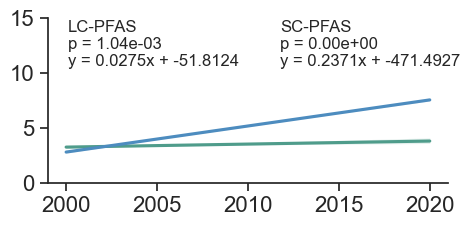

okk


'okk'

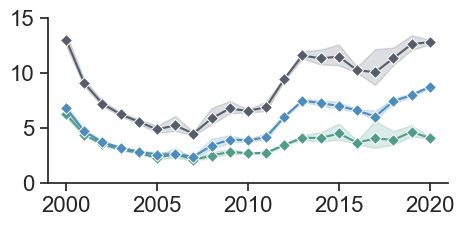

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
combined_data = pd.read_csv(path_part3_sw + 'sw_lgbm_output/final_file/sw_merge.csv')


sw_combined_data = pd.read_csv(path_part3_sw + 'sw_lgbm_output/final_file/sw.csv')

palette_colors = {"LC-PFAS": "#4f9c8b", "SC-PFAS": "#4d8cbf"}
list_regin = combined_data['region'].unique().tolist()
print(list_regin, len(list_regin))
path_save_line = path_part1_fig +  'figs5_sw_line.svg'
path_save_lm = path_part1_fig +  'figs5_sw_lm.svg'
draw_year_lm(combined_data, path_save_lm, 15, 'ng/g')
draw_year_line(sw_combined_data, path_save_line, 15,'ng/g')

In [ ]:











i=3 
str_select = list_regin[i]
df_data_select = combined_data[combined_data['region']==str_select]
print(df_data_select.shape)
df_data_select2 = sw_combined_data[sw_combined_data['region']==str_select]
print(df_data_select2.shape)
path_save_line = path_part1_fig +  'figs5_sw_' + str_select + '_line.svg'
path_save_lm = path_part1_fig +  'figs5_sw_' + str_select + '_lm.svg'
draw_year_lm(df_data_select, path_save_lm, 10, 'ng/l')
draw_year_line(df_data_select2, path_save_line, 10,'ng/l')


['High Seas', 'Pacific', 'Europe', 'North America', 'South America', 'Africa', 'Asia'] 7


e:\progress\anaconda2\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


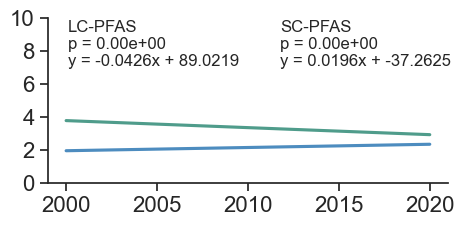

okk


'okk'

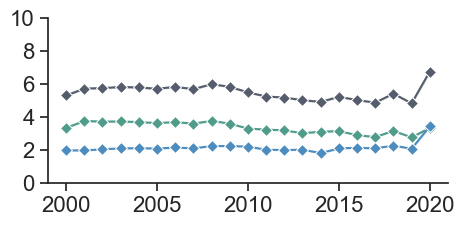

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
combined_data = pd.read_csv(path_part3_lr + 'lr_lgbm_output/final_file/lr_merge.csv')
lr_output_file_path = path_part3_lr + 'lr_lgbm_output/final_file/lr.csv'

lr_combined_data = pd.read_csv(lr_output_file_path)

palette_colors = {"LC-PFAS": "#4f9c8b", "SC-PFAS": "#4d8cbf"}
list_regin = combined_data['region'].unique().tolist()
print(list_regin, len(list_regin))
path_save_line = path_part1_fig +  'figs5_lr_line.svg'
path_save_lm = path_part1_fig +  'figs5_lr_lm.svg'
draw_year_lm(combined_data, path_save_lm, 10, 'ng/g')
draw_year_line(lr_combined_data, path_save_line, 10,'ng/g')


In [ ]:

i = 6
str_select = list_regin[i]
df_data_select = combined_data[combined_data['region']==str_select]
print(df_data_select.shape)
df_data_select2 = lr_combined_data[lr_combined_data['region']==str_select]
print(df_data_select2.shape)
path_save_line = path_part1_fig +  'figs5_lr_' + str_select + '_line.svg'
path_save_lm = path_part1_fig +  'figs5_lr_' + str_select + '_lm.svg'
draw_year_lm(df_data_select, path_save_lm, 20, 'ng/g')
draw_year_line(df_data_select2, path_save_line, 15,'ng/g')

### 处理数据

堆叠图前需要先整理一下数据  
先获取单个pfas的历年均值  
然后相加得到长短链的历年均值，以及各类别的历年均值

In [ ]:

import os
import pandas as pd

path = path_part3_sw + "/sw_lgbm_output/only_year"
list_pfas_merge = list_pfas_all.copy()  
list_pfas_merge.append('year')


df_merge = pd.DataFrame(columns=list_pfas_merge)


for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)

        df = pd.read_csv(file_path, usecols=list_pfas_merge[:-1])

        mean_values = df.mean()

        df_temp = pd.DataFrame(mean_values).transpose()
        df_temp['year'] = filename[3:7]

        df_merge = pd.concat([df_merge, df_temp])

df_merge.reset_index(drop=True, inplace=True)




df_merge['lc'] = df_merge[list_pfas_all_lc].sum(axis=1)
df_merge['sc'] = df_merge[list_pfas_all_sc].sum(axis=1)


for classification, pfas_list in classification_dict.items():

    valid_pfas = [pfas for pfas in pfas_list if pfas in df_merge.columns]
    if valid_pfas:  # Only add column if there are matching PFAS
        df_merge[classification] = df_merge[valid_pfas].sum(axis=1)


df_merge.to_csv(path_part1_data + 'sw_merge_simple.csv', index=False)






In [ ]:

df_merge_sum = df_merge.copy()
df_merge_sum['sum'] = df_merge[list_pfas_all].sum(axis=1)

df_merge_sum['per_PFOA']=df_merge_sum['PFOA']/df_merge_sum['sum']

mean_per_PFOS = df_merge_sum['per_PFOA'].mean()
median_per_PFOS = df_merge_sum['per_PFOA'].median()
max_per_PFOS = df_merge_sum['per_PFOA'].max()
min_per_PFOS = df_merge_sum['per_PFOA'].min()
std_per_PFOS = df_merge_sum['per_PFOA'].std()


print(f"Mean: {mean_per_PFOS}")
print(f"Median: {median_per_PFOS}")
print(f"Max: {max_per_PFOS}")
print(f"Min: {min_per_PFOS}")
print(f"Standard Deviation: {std_per_PFOS}")


df_merge_sum['sum_lc'] = df_merge_sum[list_pfas_all_lc].sum(axis=1)

df_merge_sum['sum_sc'] = df_merge_sum[list_pfas_all_sc].sum(axis=1)

df_merge_sum['per_lc'] = df_merge_sum['sum_lc'] / df_merge_sum['sum']

df_merge_sum['per_sc'] = df_merge_sum['sum_sc'] / df_merge_sum['sum']


mean_per_lc = df_merge_sum['per_lc'].mean()
median_per_lc = df_merge_sum['per_lc'].median()
max_per_lc = df_merge_sum['per_lc'].max()
min_per_lc = df_merge_sum['per_lc'].min()
std_per_lc = df_merge_sum['per_lc'].std()


mean_per_sc = df_merge_sum['per_sc'].mean()
median_per_sc = df_merge_sum['per_sc'].median()
max_per_sc = df_merge_sum['per_sc'].max()
min_per_sc = df_merge_sum['per_sc'].min()
std_per_sc = df_merge_sum['per_sc'].std()

print("\nLong-chain PFAS:")
print(f"Mean: {mean_per_lc}")
print(f"Median: {median_per_lc}")
print(f"Max: {max_per_lc}")
print(f"Min: {min_per_lc}")
print(f"Standard Deviation: {std_per_lc}")

print("\nShort-chain PFAS:")
print(f"Mean: {mean_per_sc}")
print(f"Median: {median_per_sc}")
print(f"Max: {max_per_sc}")
print(f"Min: {min_per_sc}")
print(f"Standard Deviation: {std_per_sc}")

df_merge_sum.to_csv(path_part1_data + 'water_year.csv')

Mean: 0.1080157567108095
Median: 0.10396366442299548
Max: 0.14479949303154233
Min: 0.0543075838250963
Standard Deviation: 0.024876419925195514

Long-chain PFAS:
Mean: 0.4177185387169449
Median: 0.4097498630030682
Max: 0.5039785225782465
Min: 0.3178807138746973
Standard Deviation: 0.058741975557102685

Short-chain PFAS:
Mean: 0.5822814612830552
Median: 0.5902501369969317
Max: 0.6821192861253025
Min: 0.4960214774217532
Standard Deviation: 0.05874197555710278


In [ ]:

import os
import pandas as pd

path = path_part3_lr + "/lr_lgbm_output/only_year"
list_pfas_merge = list_pfas_all.copy()  
list_pfas_merge.append('year')


df_merge_lr = pd.DataFrame(columns=list_pfas_merge)


for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)


        df = pd.read_csv(file_path, usecols=list_pfas_merge[:-1])


        mean_values = df.mean()


        df_temp = pd.DataFrame(mean_values).transpose()
        df_temp['year'] = filename[3:7]


        df_merge_lr = pd.concat([df_merge_lr, df_temp])


df_merge_lr.reset_index(drop=True, inplace=True)

df_merge_lr['lc'] = df_merge_lr[list_pfas_all_lc].sum(axis=1)
df_merge_lr['sc'] = df_merge_lr[list_pfas_all_sc].sum(axis=1)


for classification, pfas_list in classification_dict.items():

    valid_pfas = [pfas for pfas in pfas_list if pfas in df_merge_lr.columns]
    if valid_pfas:  # Only add column if there are matching PFAS
        df_merge_lr[classification] = df_merge_lr[valid_pfas].sum(axis=1)


df_merge_lr.to_csv(path_part1_data + 'lr_merge_simple.csv', index=False)


In [ ]:

df_merge_sum = df_merge_lr.copy()
df_merge_sum['sum'] = df_merge_sum[list_pfas_all].sum(axis=1)

df_merge_sum['per_PFOS']=df_merge_sum['PFOS']/df_merge_sum['sum']

mean_per_PFOS = df_merge_sum['per_PFOS'].mean()
median_per_PFOS = df_merge_sum['per_PFOS'].median()
max_per_PFOS = df_merge_sum['per_PFOS'].max()
min_per_PFOS = df_merge_sum['per_PFOS'].min()
std_per_PFOS = df_merge_sum['per_PFOS'].std()


print(f"Mean: {mean_per_PFOS}")
print(f"Median: {median_per_PFOS}")
print(f"Max: {max_per_PFOS}")
print(f"Min: {min_per_PFOS}")
print(f"Standard Deviation: {std_per_PFOS}")


df_merge_sum['sum_lc'] = df_merge_sum[list_pfas_all_lc].sum(axis=1)


df_merge_sum['sum_sc'] = df_merge_sum[list_pfas_all_sc].sum(axis=1)


df_merge_sum['per_lc'] = df_merge_sum['sum_lc'] / df_merge_sum['sum']


df_merge_sum['per_sc'] = df_merge_sum['sum_sc'] / df_merge_sum['sum']


mean_per_lc = df_merge_sum['per_lc'].mean()
median_per_lc = df_merge_sum['per_lc'].median()
max_per_lc = df_merge_sum['per_lc'].max()
min_per_lc = df_merge_sum['per_lc'].min()
std_per_lc = df_merge_sum['per_lc'].std()


mean_per_sc = df_merge_sum['per_sc'].mean()
median_per_sc = df_merge_sum['per_sc'].median()
max_per_sc = df_merge_sum['per_sc'].max()
min_per_sc = df_merge_sum['per_sc'].min()
std_per_sc = df_merge_sum['per_sc'].std()


print("\nLong-chain PFAS:")
print(f"Mean: {mean_per_lc}")
print(f"Median: {median_per_lc}")
print(f"Max: {max_per_lc}")
print(f"Min: {min_per_lc}")
print(f"Standard Deviation: {std_per_lc}")

print("\nShort-chain PFAS:")
print(f"Mean: {mean_per_sc}")
print(f"Median: {median_per_sc}")
print(f"Max: {max_per_sc}")
print(f"Min: {min_per_sc}")
print(f"Standard Deviation: {std_per_sc}")

df_merge_sum.to_csv(path_part1_data + 'biota_year.csv')

Mean: 0.13787935850918437
Median: 0.13088568812193396
Max: 0.19845112412320634
Min: 0.08194402718411851
Standard Deviation: 0.029265309006930435

Long-chain PFAS:
Mean: 0.609979502631424
Median: 0.616559021129022
Max: 0.65667703321795
Min: 0.49311240852544996
Standard Deviation: 0.0366978182381587

Short-chain PFAS:
Mean: 0.3900204973685759
Median: 0.38344097887097855
Max: 0.50688759147455
Min: 0.34332296678204993
Standard Deviation: 0.03669781823815864


### 堆叠图

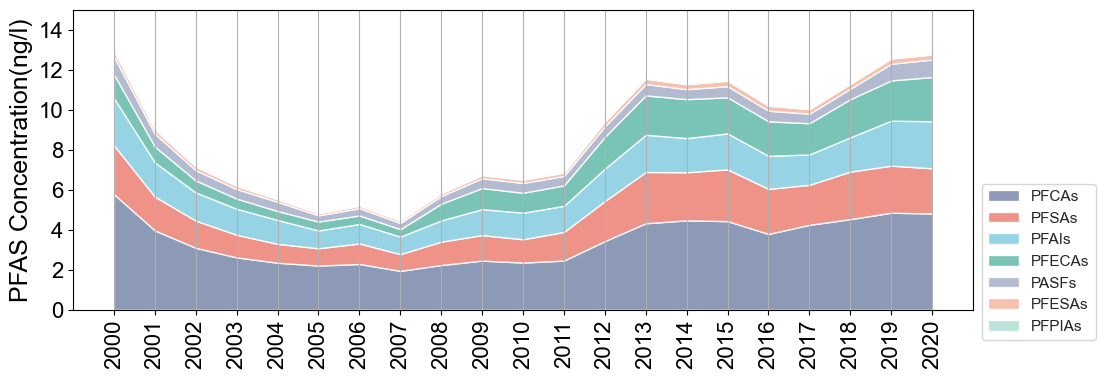

'okk'

In [ ]:

df_merge = pd.read_csv(path_part1_data + 'sw_merge_simple.csv')
df_sw_classfication = df_merge.copy()
df_sw_classfication = df_sw_classfication[list_pfas_classification + ['year']]
df_sw_classfication[["year"]] = df_sw_classfication[["year"]].astype(str)

draw_year_gpfas(df_sw_classfication, path_part1_fig,'sw', 15, dic_color_classfication)

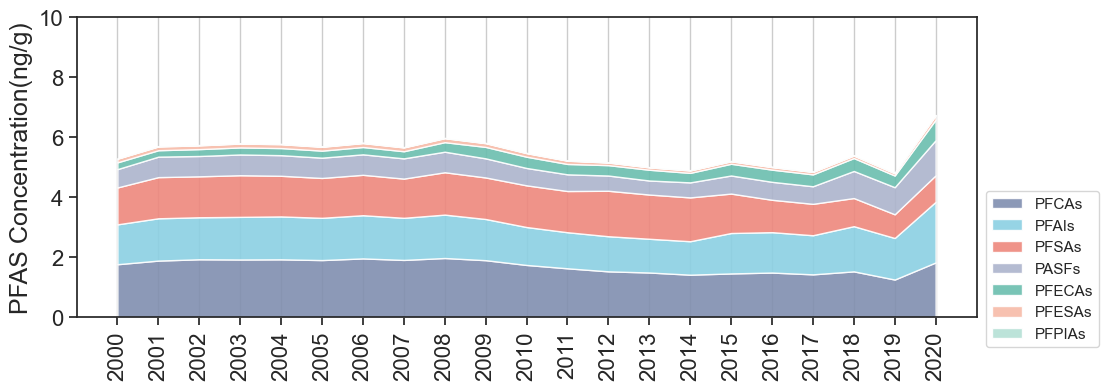

'okk'

In [47]:
df_lr_classfication = df_merge_lr.copy()
df_lr_classfication = df_lr_classfication[list_pfas_classification + ['year']]
draw_year_gpfas(df_lr_classfication, path_part1_fig,'lr', 10, dic_color_classfication)

### 描述

In [ ]:

df_grid_re = pd.read_csv(path_parts_data + 'grid_re.csv')
sw_path_year = path_part3_sw + 'sw_lgbm_output/final_file/'
df_sw = pd.read_csv(sw_path_year + 'sw_year.csv')
df_sw_s = df_sw[['lon_grid', 'lat_grid', 'slope']].copy()
df_sw_s.rename(columns={'lon_grid': 'lon', 'lat_grid': 'lat'}, inplace=True)
lr_path_year = path_part3_lr + 'lr_lgbm_output/final_file/'
df_lr = pd.read_csv(lr_path_year + 'lr_year.csv')
df_lr_s = df_lr[['lon_grid', 'lat_grid', 'slope']].copy()
df_lr_s.rename(columns={'lon_grid': 'lon', 'lat_grid': 'lat'}, inplace=True)

lr_merged_df = pd.merge(df_lr_s, df_grid_re, on=['lon', 'lat'], how='left')
sw_merged_df = pd.merge(df_sw_s, df_grid_re, on=['lon', 'lat'], how='left')


sw_ocean_water = sw_merged_df[sw_merged_df['ocean_water'] == 1]['slope']
sw_ocean_water_positive = sw_ocean_water[sw_ocean_water > 0]
sw_ocean_water_positive_ratio = len(sw_ocean_water_positive) / len(sw_ocean_water)
print(f"SW Ocean Water Positive Slope Ratio: {sw_ocean_water_positive_ratio:.2%}")


df_sw_lc = pd.read_csv(sw_path_year + 'sw_lc_year.csv')
df_sw_sc = pd.read_csv(sw_path_year + 'sw_sc_year.csv')
df_sw_s_lc = df_sw_lc[['lon_grid', 'lat_grid', 'slope']].copy()
df_sw_s_lc.rename(columns={'lon_grid': 'lon', 'lat_grid': 'lat'}, inplace=True)
df_sw_s_sc = df_sw_sc[['lon_grid', 'lat_grid', 'slope']].copy()
df_sw_s_sc.rename(columns={'lon_grid': 'lon', 'lat_grid': 'lat'}, inplace=True)

sw_merged_df_lc = pd.merge(df_sw_s_lc, df_grid_re, on=['lon', 'lat'], how='left')
sw_merged_df_sc = pd.merge(df_sw_s_sc, df_grid_re, on=['lon', 'lat'], how='left')
sw_merged_df_lc.to_csv(path_part3_temp + 'sw_lc_year.csv', index=False)
sw_inland_water_lc = sw_merged_df_lc[sw_merged_df_lc['inland_water'] == 1]['slope']
sw_inland_water_positive_lc = sw_inland_water_lc[sw_inland_water_lc > 0]
sw_inland_water_positive_ratio_lc = len(sw_inland_water_positive_lc) / len(sw_inland_water_lc)
print(f"LC-PFAS SW inland_water + Slope Ratio: {sw_inland_water_positive_ratio_lc:.2%}")

sw_ocean_water_lc = sw_merged_df_lc[sw_merged_df_lc['ocean_water'] == 1]['slope']
sw_ocean_water_positive_lc = sw_ocean_water_lc[sw_ocean_water_lc > 0]
sw_ocean_water_positive_ratio_lc = len(sw_ocean_water_positive_lc) / len(sw_ocean_water_lc)
print(f"LC-PFAS SW ocean_water + Slope Ratio: {sw_ocean_water_positive_ratio_lc:.2%}")


sw_slope_positive_lc = sw_merged_df_lc['slope'][sw_merged_df_lc['slope'] > 0]
sw_slope_positive_ratio_lc = len(sw_slope_positive_lc) / len(sw_merged_df_lc['slope'])    
print(f"LC-PFAS SW Slope + Ratio: {sw_slope_positive_ratio_lc:.2%}")


sw_ocean_water_sc = sw_merged_df_sc[sw_merged_df_sc['ocean_water'] == 1]['slope']
sw_ocean_water_positive_sc = sw_ocean_water_sc[sw_ocean_water_sc > 0]
sw_ocean_water_positive_ratio_sc = len(sw_ocean_water_positive_sc) / len(sw_ocean_water_sc)
print(f"SC-PFAS SW ocean_water + Slope Ratio: {sw_ocean_water_positive_ratio_sc:.2%}")

sw_inland_water_sc = sw_merged_df_sc[sw_merged_df_sc['inland_water'] == 1]['slope']
sw_inland_water_positive_sc = sw_inland_water_sc[sw_inland_water_sc > 0]
sw_inland_water_positive_ratio_sc = len(sw_inland_water_positive_sc) / len(sw_inland_water_sc)
print(f"SC-PFAS SW inland_water + Slope Ratio: {sw_inland_water_positive_ratio_sc:.2%}")



sw_slope_positive_sc = sw_merged_df_sc['slope'][sw_merged_df_sc['slope'] > 0]
sw_slope_positive_ratio_sc = len(sw_slope_positive_sc) / len(sw_merged_df_sc['slope'])
print(f"SC-PFAS SW Slope + Ratio: {sw_slope_positive_ratio_sc:.2%}")


df_lr_lc = pd.read_csv(lr_path_year + 'lr_lc_year.csv')
df_lr_sc = pd.read_csv(lr_path_year + 'lr_sc_year.csv')
df_lr_s_lc = df_lr_lc[['lon_grid', 'lat_grid', 'slope']].copy()
df_lr_s_lc.rename(columns={'lon_grid': 'lon', 'lat_grid': 'lat'}, inplace=True)
df_lr_s_sc = df_lr_sc[['lon_grid', 'lat_grid', 'slope']].copy()
df_lr_s_sc.rename(columns={'lon_grid': 'lon', 'lat_grid': 'lat'}, inplace=True)
lr_merged_df_lc = pd.merge(df_lr_s_lc, df_grid_re, on=['lon', 'lat'], how='left')
lr_merged_df_sc = pd.merge(df_lr_s_sc, df_grid_re, on=['lon', 'lat'], how='left')
lr_ocean_water_lc = lr_merged_df_lc[lr_merged_df_lc['ocean_water'] == 1]['slope']
lr_ocean_water_positive_lc = lr_ocean_water_lc[lr_ocean_water_lc < 0]
lr_ocean_water_positive_ratio_lc = len(lr_ocean_water_positive_lc) / len(lr_ocean_water_lc)
print(f"LC-PFAS LR ocean_water - Slope Ratio: {lr_ocean_water_positive_ratio_lc:.2%}")   
lr_ocean_water_sc = lr_merged_df_sc[lr_merged_df_sc['ocean_water'] == 1]['slope']
lr_ocean_water_positive_sc = lr_ocean_water_sc[lr_ocean_water_sc > 0]
lr_ocean_water_positive_ratio_sc = len(lr_ocean_water_positive_sc) / len(lr_ocean_water_sc)
print(f"SC-PFAS LR ocean_water + Slope Ratio: {lr_ocean_water_positive_ratio_sc:.2%}")


lr_slope_positive_lc = lr_merged_df_lc['slope'][lr_merged_df_lc['slope'] < 0]
lr_slope_positive_ratio_lc = len(lr_slope_positive_lc) / len(lr_merged_df_lc['slope'])
print(f"LC-PFAS LR Slope - Ratio: {lr_slope_positive_ratio_lc:.2%}")


lr_inland_water_lc = lr_merged_df_lc[lr_merged_df_lc['inland_water'] == 1]['slope']
lr_inland_water_positive_lc = lr_inland_water_lc[lr_inland_water_lc < 0]
lr_inland_water_positive_ratio_lc = len(lr_inland_water_positive_lc) / len(lr_inland_water_lc)
print(f"LC-PFAS LR inland_water - Slope Ratio: {lr_inland_water_positive_ratio_lc:.2%}")
lr_inland_water_sc = lr_merged_df_sc[lr_merged_df_sc['inland_water'] == 1]['slope']
lr_inland_water_positive_sc = lr_inland_water_sc[lr_inland_water_sc > 0]
lr_inland_water_positive_ratio_sc = len(lr_inland_water_positive_sc) / len(lr_inland_water_sc)
print(f"SC-PFAS LR inland_water + Slope Ratio: {lr_inland_water_positive_ratio_sc:.2%}")


lr_slope_positive_sc = lr_merged_df_sc['slope'][lr_merged_df_sc['slope'] > 0]
lr_slope_positive_ratio_sc = len(lr_slope_positive_sc) / len(lr_merged_df_sc['slope'])
print(f"SC-PFAS LR Slope + Ratio: {lr_slope_positive_ratio_sc:.2%}")


SW Ocean Water Positive Slope Ratio: 82.92%
LC-PFAS SW inland_water + Slope Ratio: 71.07%
LC-PFAS SW ocean_water + Slope Ratio: 70.52%
LC-PFAS SW Slope + Ratio: 71.95%
SC-PFAS SW ocean_water + Slope Ratio: 88.59%
SC-PFAS SW inland_water + Slope Ratio: 90.27%
SC-PFAS SW Slope + Ratio: 90.12%
LC-PFAS LR ocean_water - Slope Ratio: 81.32%
SC-PFAS LR ocean_water + Slope Ratio: 66.63%
LC-PFAS LR Slope - Ratio: 75.91%
LC-PFAS LR inland_water - Slope Ratio: 66.55%
SC-PFAS LR inland_water + Slope Ratio: 67.70%
SC-PFAS LR Slope + Ratio: 66.64%
